<h3><b>1. Load the Cleaned Dataset <b><h3>

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import MinMaxScaler, Normalizer

PROJECT_ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "data" / "processed" / "concrete_data_cleaned.csv").exists()
)

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "concrete_data_cleaned.csv"
FEATURES_PATH = PROJECT_ROOT / "data" / "processed"
FIGURES_PATH = PROJECT_ROOT / "reports" / "figures"
FEATURES_PATH.mkdir(parents=True, exist_ok=True)
FIGURES_PATH.mkdir(parents=True, exist_ok=True)
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (911, 9)


,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
1,266.0,114.0,0.0,228.0,0.0,932.0,670.0,90,47.03
2,380.0,95.0,0.0,228.0,0.0,932.0,594.0,28,36.45
3,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.85
4,475.0,0.0,0.0,228.0,0.0,932.0,594.0,28,39.29


<h3><b>2. Separate Features and Target <b><h3>

In [2]:
target_column = "compressive_strength"

X = df.drop(columns=[target_column])
y = df[target_column]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (911, 8)
Target shape: (911,)


<h3><b>3. Min-Max Scaling <b><h3>

In [3]:
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index,
)

print("Minimum value of each scaled feature:")
print(X_scaled.min())
print("\nMaximum value of each scaled feature:")
print(X_scaled.max())
display(X_scaled.head())

Minimum value of each scaled feature:
cement                0.0
blast_furnace_slag    0.0
fly_ash               0.0
water                 0.0
superplasticizer      0.0
coarse_aggregate      0.0
fine_aggregate        0.0
age                   0.0
dtype: float64

Maximum value of each scaled feature:
cement                1.0
blast_furnace_slag    1.0
fly_ash               1.0
water                 1.0
superplasticizer      1.0
coarse_aggregate      1.0
fine_aggregate        1.0
age                   1.0
dtype: float64


,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age
0,1.000000,0.000000,0.0,0.344588,0.113122,0.738372,0.233618,0.226891
1,0.374429,0.333236,0.0,1.000000,0.000000,0.380814,0.216524,0.747899
2,0.634703,0.277697,0.0,1.000000,0.000000,0.380814,0.000000,0.226891
3,0.374429,0.333236,0.0,1.000000,0.000000,0.380814,0.216524,0.226891
4,0.851598,0.000000,0.0,1.000000,0.000000,0.380814,0.000000,0.226891


Saved normalized features to D:\My Projects\Concrete-Compressive-Strength-Predictor\data\processed\concrete_features_normalized.csv


,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age
0,0.748945,0.000000,0.0,0.258078,0.084722,0.553000,0.174967,0.169929
1,0.264596,0.235486,0.0,0.706666,0.000000,0.269108,0.153010,0.528515
2,0.490201,0.214474,0.0,0.772330,0.000000,0.294114,0.000000,0.175235
3,0.306269,0.272575,0.0,0.817963,0.000000,0.311492,0.177109,0.185588
4,0.614313,0.000000,0.0,0.721365,0.000000,0.274706,0.000000,0.163671


<h3><b>4. L2 Normalization <b><h3>

In [ ]:
normalizer = Normalizer(norm='l2')
X_normalized = pd.DataFrame(
    normalizer.fit_transform(X_scaled),
    columns=X_scaled.columns,
    index=X_scaled.index,
)

normalized_dataset = X_normalized.copy()
normalized_dataset[target_column] = y.to_numpy()
normalized_dataset.to_csv(FEATURES_PATH / 'concrete_features_normalized.csv', index=False)

print(f"Saved normalized features to {FEATURES_PATH / 'concrete_features_normalized.csv'}")
display(X_normalized.head())

<h3><b>5. Feature Selection Using Variance Threshold <b><h3>

In [4]:
variance_selector = VarianceThreshold(threshold=0.01)
X_selected_array = variance_selector.fit_transform(X_normalized)

selected_features = X_normalized.columns[variance_selector.get_support()].tolist()
removed_features = X_normalized.columns[~variance_selector.get_support()].tolist()

X_selected = pd.DataFrame(
    X_selected_array,
    columns=selected_features,
    index=X_scaled.index,
)

feature_variances = pd.DataFrame({
    "Feature": X_normalized.columns,
    "Variance": variance_selector.variances_,
    "Selected": variance_selector.get_support(),
})

display(feature_variances)
print("Selected features:", selected_features)
print("Removed features:", removed_features if removed_features else "None")
print("Shape after feature selection:", X_selected.shape)

,Feature,Variance,Selected
0,cement,0.031032,True
1,blast_furnace_slag,0.040144,True
2,fly_ash,0.057192,True
3,water,0.022596,True
4,superplasticizer,0.030591,True
5,coarse_aggregate,0.028560,True
6,fine_aggregate,0.026614,True
7,age,0.025584,True


Selected features: ['cement', 'blast_furnace_slag', 'fly_ash', 'water', 'superplasticizer', 'coarse_aggregate', 'fine_aggregate', 'age']
Removed features: None
Shape after feature selection: (911, 8)


<h3><b>6. Dimensionality Reduction Using PCA <b><h3>

,Principal Component,Explained Variance Ratio,Cumulative Explained Variance
0,PC1,0.318957,0.318957
1,PC2,0.187190,0.506148
2,PC3,0.138354,0.644502
3,PC4,0.115999,0.760500
4,PC5,0.107601,0.868101
5,PC6,0.102144,0.970245


Features before PCA: 8
Principal components retained: 6


,PC1,PC2,PC3,PC4,PC5,PC6
0,-0.256103,-0.419761,0.255188,-0.244308,-0.075609,0.072283
1,-0.360452,0.130321,-0.045929,-0.111443,0.377912,0.239140
2,-0.449968,0.014563,0.122052,-0.291394,0.324652,-0.105743
3,-0.426534,0.120793,-0.044620,-0.130374,0.280478,-0.107348
4,-0.398173,-0.208623,0.208630,-0.277136,0.367770,-0.109080


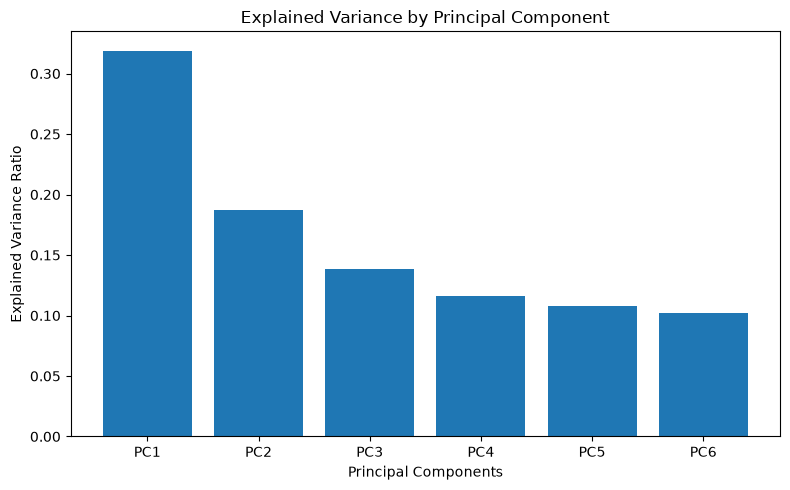

In [5]:
pca = PCA(n_components=0.95)
X_pca_array = pca.fit_transform(X_selected)

pca_columns = [f"PC{i + 1}" for i in range(X_pca_array.shape[1])]
X_pca = pd.DataFrame(
    X_pca_array,
    columns=pca_columns,
    index=X_selected.index,
)

explained_variance = pd.DataFrame({
    "Principal Component": pca_columns,
    "Explained Variance Ratio": pca.explained_variance_ratio_,
    "Cumulative Explained Variance": np.cumsum(pca.explained_variance_ratio_),
})

display(explained_variance)
print("Features before PCA:", X_selected.shape[1])
print("Principal components retained:", X_pca.shape[1])
display(X_pca.head())

plt.figure(figsize=(8, 5))
plt.bar(pca_columns, pca.explained_variance_ratio_)
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Principal Component')
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'pca_explained_variance.png', dpi=300)
plt.show()
plt.close()

<h3><b>7. PCA Feature Loadings and Contributions for All Principal Components <b><h3>

In [6]:
pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=X_selected.columns,
    columns=[f"PC{i + 1}" for i in range(pca.n_components_)],
)

print("Feature loadings for all Principal Components:")
display(pca_loadings)

for pc in pca_loadings.columns:
    pc_contributions = pd.DataFrame({
        "Loading": pca_loadings[pc],
        "Absolute Contribution": pca_loadings[pc].abs(),
    })

    pc_contributions = pc_contributions.sort_values(
        by="Absolute Contribution",
        ascending=False,
    )

    print(f"\nFeatures contributing to {pc}:")
    display(pc_contributions)

Feature loadings for all Principal Components:


,PC1,PC2,PC3,PC4,PC5,PC6
cement,-0.200291,-0.438963,0.675214,-0.123730,0.075681,-0.078686
blast_furnace_slag,-0.281409,0.786589,0.074728,-0.091341,-0.256091,-0.004034
fly_ash,0.774491,0.091872,-0.144827,-0.225344,0.278963,-0.224381
water,-0.298269,0.117842,-0.174471,-0.040330,0.532338,-0.350648
superplasticizer,0.417518,0.191797,0.470027,-0.019207,-0.359419,0.076994
coarse_aggregate,-0.079367,-0.337857,-0.485506,-0.425551,-0.520330,0.101025
fine_aggregate,0.099029,-0.114137,-0.169303,0.861305,-0.193990,-0.061331
age,0.038271,0.047982,-0.042210,0.025131,0.360455,0.894760



Features contributing to PC1:


,Loading,Absolute Contribution
fly_ash,0.774491,0.774491
superplasticizer,0.417518,0.417518
water,-0.298269,0.298269
blast_furnace_slag,-0.281409,0.281409
cement,-0.200291,0.200291
fine_aggregate,0.099029,0.099029
coarse_aggregate,-0.079367,0.079367
age,0.038271,0.038271



Features contributing to PC2:


...

,Loading,Absolute Contribution
fine_aggregate,0.861305,0.861305
coarse_aggregate,-0.425551,0.425551
fly_ash,-0.225344,0.225344
cement,-0.123730,0.123730
blast_furnace_slag,-0.091341,0.091341
water,-0.040330,0.040330
age,0.025131,0.025131
superplasticizer,-0.019207,0.019207



Features contributing to PC5:


,Loading,Absolute Contribution
water,0.532338,0.532338
coarse_aggregate,-0.520330,0.520330
age,0.360455,0.360455
superplasticizer,-0.359419,0.359419
fly_ash,0.278963,0.278963
blast_furnace_slag,-0.256091,0.256091
fine_aggregate,-0.193990,0.193990
cement,0.075681,0.075681



Features contributing to PC6:


,Loading,Absolute Contribution
age,0.894760,0.894760
water,-0.350648,0.350648
fly_ash,-0.224381,0.224381
coarse_aggregate,0.101025,0.101025
cement,-0.078686,0.078686
superplasticizer,0.076994,0.076994
fine_aggregate,-0.061331,0.061331
blast_furnace_slag,-0.004034,0.004034


<h3><b>8. Final PCA Dataset <b><h3>

In [7]:
pca_dataset = X_pca.copy()
pca_dataset[target_column] = y.to_numpy()

pca_dataset.to_csv(FEATURES_PATH / "concrete_data_pca.csv", index=False)
display(pca_dataset.head())
print("Final PCA dataset shape:", pca_dataset.shape)
print(f"Saved PCA data to {FEATURES_PATH / 'concrete_data_pca.csv'}")

,PC1,PC2,PC3,PC4,PC5,PC6,compressive_strength
0,-0.256103,-0.419761,0.255188,-0.244308,-0.075609,0.072283,61.89
1,-0.360452,0.130321,-0.045929,-0.111443,0.377912,0.239140,47.03
2,-0.449968,0.014563,0.122052,-0.291394,0.324652,-0.105743,36.45
3,-0.426534,0.120793,-0.044620,-0.130374,0.280478,-0.107348,45.85
4,-0.398173,-0.208623,0.208630,-0.277136,0.367770,-0.109080,39.29


Final PCA dataset shape: (911, 7)
Saved PCA data to D:\My Projects\Concrete-Compressive-Strength-Predictor\data\processed\concrete_data_pca.csv
